In [1]:
import os
from dotenv import load_dotenv
import anthropic
from openai import OpenAI
from google import genai
from functions import text_vectorize_score, code_vectorize_score, data_completion_score
from sentence_transformers import SentenceTransformer
from bert_score import BERTScorer
from tqdm.notebook import tqdm
import code_bert_score
from transformers import AutoTokenizer, AutoModel

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [2]:
from google.genai import types

def ai_outputs(client, message, ai_type):

    match ai_type:
        case "claude":
            response = client.messages.create(
                model="claude-opus-4-8",
                max_tokens=500,
                output_config={
                    "effort":"medium"
                },
                messages=[
                    {"role": "user", "content": message}
                ]
            ) 

            return response.content[0].text           
        case "chatgpt":
            response = client.chat.completions.create(
                model="gpt-5.5",
                max_completion_tokens=8192,
                reasoning_effort="medium",
                messages=[
                    {"role": "user", "content": message}
                ]
            )

            #print(response.choices[0].message.content)
            return response.choices[0].message.content
        
        case "gemini":
            response = client.models.generate_content(
                model="gemini-3.1-flash-lite",
                contents=message,
                config=types.GenerateContentConfig(
                    max_output_tokens=500,
                    thinking_config=types.ThinkingConfig(
                        thinking_level="MEDIUM"
                    )
                )
            )

            return response.text

        case "glm":
            response = client.chat.completions.create(
                model="glm-5.2",
                max_tokens=500,
                reasoning_effort="medium",
                messages=[
                    {"role": "user", "content": message}
                ]
            )

            return response.choices[0].message.content

In [3]:
def ai_test_trials(client, message, ground_truth, dataset: str, ai_type: str, num_iter):
    match dataset:
        case "ROCStories":
            model = SentenceTransformer("nomic-ai/nomic-embed-text-v1.5", trust_remote_code=True)
            bert_scorer = BERTScorer(lang="en", model_type="distilbert-base-uncased")

            F1_array = []
            cosine_array = []

            try:
                for i in tqdm(range(num_iter)):
                    prediction = ai_outputs(client, message, ai_type)

                    result = text_vectorize_score(prediction, ground_truth, model, bert_scorer)

                    F1_array.append(result["BERTScore_F1"])
                    cosine_array.append(float(result["cosine_similarity"]))

                return {
                    "cosine_array": cosine_array,
                    "F1_array": F1_array
                }

            except anthropic.APIConnectionError as e:
                print("The server could not be reached", e.__cause__)
                return e
            except anthropic.RateLimitError:
                print("A 429 status code was received; consider backoff optimization.")
                return e
            except anthropic.APIStatusError as e:
                print(f"Another non-200 response was received (Status: {e.status_code})")
                print(e.response) 
                return e

        case "HumanEval":

            tokenizer = AutoTokenizer.from_pretrained("microsoft/unixcoder-base")
            model = AutoModel.from_pretrained("microsoft/unixcoder-base")

            from code_bert_score import BERTScorer

            scorer_instance = BERTScorer(model_type="microsoft/unixcoder-base", lang="python")

            F1_array = []
            cosine_array = []

            try:
                for i in tqdm(range(num_iter)):

                    prediction = ai_outputs(client, message, ai_type)

                    result = code_vectorize_score(prediction, ground_truth, tokenizer, model, scorer_instance)

                    F1_array.append(result["BERTScore_F1"])
                    cosine_array.append(float(result["cosine_similarity"]))

                return {
                    "cosine_array": cosine_array,
                    "F1_array": F1_array
                }

            except anthropic.APIConnectionError as e:
                print("The server could not be reached", e.__cause__)
                return e
            except anthropic.RateLimitError:
                print("A 429 status code was received; consider backoff optimization.")
                return e
            except anthropic.APIStatusError as e:
                print(f"Another non-200 response was received (Status: {e.status_code})")
                print(e.response) 
                return e

        case "AMES":
            error_array = []

            try:
                for i in tqdm(range(num_iter)):
                    prediction = ai_outputs(client, message, ai_type)
                    prediction = float(prediction)

                    result = data_completion_score(prediction, ground_truth)

                    error_array.append(result)

                return {
                    "error_array": error_array
                }
                
            except Exception as e:
                print(f"Error happend in data completion: {e}")
                return e
        


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def process_data(dataset_type, cosine_array=None, F1_array=None, MSE_array=None):
    if dataset_type == "ROCStories" or dataset_type == "HumanEval":
        cos_mean_val = np.mean(cosine_array)
        cos_median_val = np.median(cosine_array)
        cos_q1 = np.percentile(cosine_array, 25)
        cos_q3 = np.percentile(cosine_array, 75)
        cos_iqr_val = cos_q3 - cos_q1
        cos_data_range = np.ptp(cosine_array)
        cos_std_dev = np.std(cosine_array)
        cos_lower_whisker = cos_q1 - (1.5 * cos_iqr_val)
        cos_upper_whisker = cos_q3 + (1.5 * cos_iqr_val)

        F1_mean_val = np.mean(F1_array)
        F1_median_val = np.median(F1_array)
        F1_q1 = np.percentile(F1_array, 25)
        F1_q3 = np.percentile(F1_array, 75)
        F1_iqr_val = F1_q3 - F1_q1
        F1_lower_whisker = F1_q1 - (1.5 * F1_iqr_val)
        F1_upper_whisker = F1_q3 + (1.5 * F1_iqr_val)
        F1_data_range = np.ptp(F1_array)
        F1_std_dev = np.std(F1_array)

        print(f"=======================================")
        print(f"Cosine Similarity\n")
        print(f"Mean (Average):     {cos_mean_val:.4f}")
        print(f"Median (Middle):    {cos_median_val:.4f}")
        print(f"25th Percentile(Q1): {cos_q1:.4f}")
        print(f"75th Percentile(Q3): {cos_q3:.4f}")
        print(f"IQR (Q3 - Q1):      {cos_iqr_val:.4f}")
        print(f"Lower Whisker Limit: {cos_lower_whisker:.4f}")
        print(f"Upper Whisker Limit: {cos_upper_whisker:.4f}")
        print(f"Range (Max - Min):  {cos_data_range:.4f}")
        print(f"Std Deviation:      {cos_std_dev:.4f}\n")

        print(f"=======================================")
        print(f"F1 Score\n")
        print(f"Mean (Average):     {F1_mean_val:.4f}")
        print(f"Median (Middle):    {F1_median_val:.4f}")
        print(f"25th Percentile(Q1): {F1_q1:.4f}")
        print(f"75th Percentile(Q3): {F1_q3:.4f}")
        print(f"IQR (Q3 - Q1):      {F1_iqr_val:.4f}")
        print(f"Lower Whisker Limit: {F1_lower_whisker:.4f}")
        print(f"Upper Whisker Limit: {F1_upper_whisker:.4f}")
        print(f"Range (Max - Min):  {F1_data_range:.4f}")
        print(f"Std Deviation:      {F1_std_dev:.4f}")
        print(f"\n")

        sns.set_theme(style="whitegrid")
        fig, axes = plt.subplots(2, 2, figsize=(14, 5))

        sns.histplot(cosine_array, bins=15, kde=True, color="skyblue", edgecolor="black", linewidth=1, ax = axes[0][0])
        axes[0][0].set_title("Distribution of Cosine Similarity", fontsize=14, fontweight="bold", pad=15)
        axes[0][0].set_xlabel("Value / Score", fontsize=12)
        axes[0][0].set_ylabel("Frequency (Count)", fontsize=12)

        sns.boxplot(x=cosine_array, ax=axes[0][1], color="lightcoral")
        axes[0][1].set_title("Cosine Outlier Detection (Box Plot)")
        axes[0][1].set_ylabel("Value")



        sns.histplot(F1_array, bins=15, kde=True, color="skyblue", edgecolor="black", linewidth=1, ax = axes[1][0])
        axes[1][0].set_title("Distribution of F1 Scores", fontsize=14, fontweight="bold", pad=15)
        axes[1][0].set_xlabel("Value / Score", fontsize=12)
        axes[1][0].set_ylabel("Frequency (Count)", fontsize=12)

        sns.boxplot(x=F1_array, ax=axes[1][1], color="lightcoral")
        axes[1][1].set_title("F1 Outlier Detection (Box Plot)")
        axes[1][1].set_ylabel("Value")

        plt.tight_layout()
        plt.show()

    elif dataset_type == "AMES":

        MSE_mean_val = np.mean(MSE_array)
        MSE_median_val = np.median(MSE_array)
        MSE_q1 = np.percentile(MSE_array, 25)
        MSE_q3 = np.percentile(MSE_array, 75)
        MSE_iqr_val = MSE_q3 - MSE_q1
        MSE_data_range = np.ptp(MSE_array)
        MSE_std_dev = np.std(MSE_array)
        MSE_lower_whisker = MSE_q1 - (1.5 * MSE_iqr_val)
        MSE_upper_whisker = MSE_q3 + (1.5 * MSE_iqr_val)

        print(f"=======================================")
        print(f"MSE\n")
        print(f"Mean (Average):     {MSE_mean_val:.4f}")
        print(f"Median (Middle):    {MSE_median_val:.4f}")
        print(f"25th Percentile(Q1): {MSE_q1:.4f}")
        print(f"75th Percentile(Q3): {MSE_q3:.4f}")
        print(f"IQR (Q3 - Q1):      {MSE_iqr_val:.4f}")
        print(f"Lower Whisker Limit: {MSE_lower_whisker:.4f}")
        print(f"Upper Whisker Limit: {MSE_upper_whisker:.4f}")
        print(f"Range (Max - Min):  {MSE_data_range:.4f}")
        print(f"Std Deviation:      {MSE_std_dev:.4f}\n")
        print(f"\n")

        sns.set_theme(style="whitegrid")
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        sns.histplot(MSE_array, bins=15, kde=True, color="skyblue", edgecolor="black", linewidth=1, ax = axes[0])
        axes[0].set_title("Distribution of MSE Scores", fontsize=14, fontweight="bold", pad=15)
        axes[0].set_xlabel("Value / Score", fontsize=12)
        axes[0].set_ylabel("Frequency (Count)", fontsize=12)

        sns.boxplot(x=MSE_array, ax=axes[1], color="lightcoral")
        axes[1].set_title("F1 Outlier Detection (Box Plot)")
        axes[1].set_ylabel("Value")

        plt.tight_layout()
        plt.show()



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

[0.8307977914810181, 0.7439049482345581, 0.6215524077415466, 0.44830793142318726, 0.8596474528312683, 0.8630765676498413, 0.785730242729187, 0.8702495098114014, 0.8257390856742859, 0.594075083732605, 0.8392175436019897, 0.7569875717163086, 0.8275032043457031, 0.58659827709198, 0.8401618003845215]
Cosine Similarity

Mean (Average):     0.7529
Median (Middle):    0.8257
25th Percentile(Q1): 0.6827
75th Percentile(Q3): 0.8397
IQR (Q3 - Q1):      0.1570
Lower Whisker Limit: 0.4473
Upper Whisker Limit: 1.0751
Range (Max - Min):  0.4219
Std Deviation:      0.1247

F1 Score

Mean (Average):     0.7950
Median (Middle):    0.8243
25th Percentile(Q1): 0.7600
75th Percentile(Q3): 0.8291
IQR (Q3 - Q1):      0.0691
Lower Whisker Limit: 0.6564
Upper Whisker Limit: 0.9327
Range (Max - Min):  0.2080
Std Deviation:      0.0536




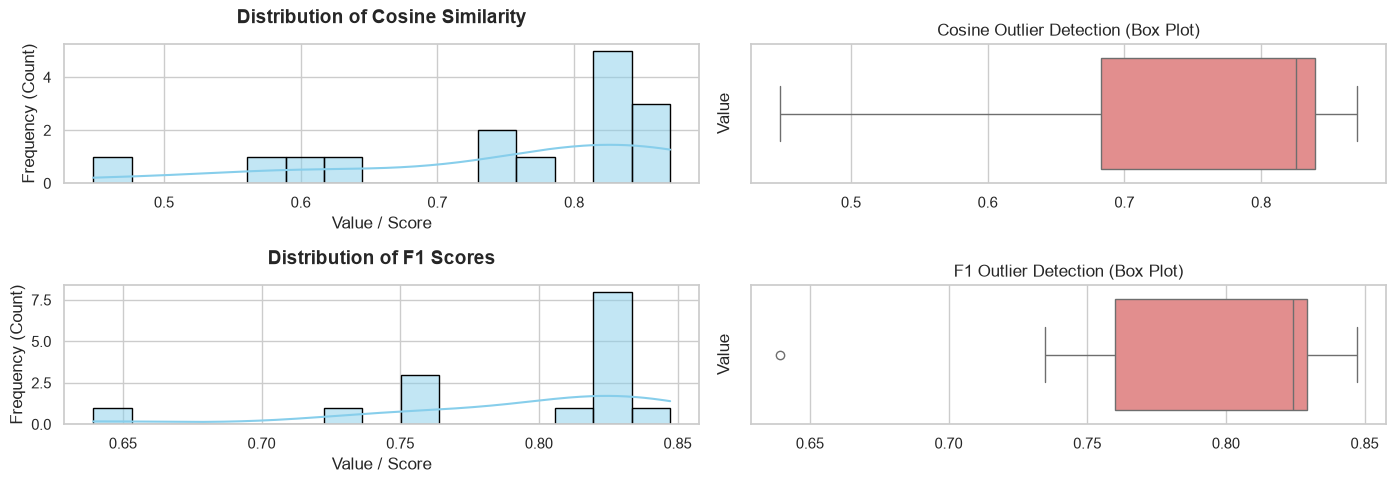

In [ ]:
load_dotenv(override=True)

api_key = os.getenv("OPENAI_API_KEY")

if not api_key:
    raise ValueError("API_KEY is missing from environment variables!")

#client = anthropic.Anthropic(api_key=api_key)

client = OpenAI(api_key=api_key)


# message_text = """
#     Analyze the story and finish the last sentence. Your response should only be 
#     ONE sentence which is the final sentence that completes the story:

#     Sherry hates basketball. 
#     Sherry's boyfriend Tom loves basketball. 
#     Sherry tries to learn more about basketball to make Tom happy. 
#     For Tom's birthday she surprises him with tickets to a game. 
# """


message_code = """
Analyze the function signature and docstring, and provide a finished function. 
Your response should ONLY be the full completed function (not including the signature and docstring).

def encode(message):
    "
    Write a function that takes a message, and encodes in such a 
    way that it swaps case of all letters, replaces all vowels in 
    the message with the letter that appears 2 places ahead of that 
    vowel in the english alphabet. 
    Assume only letters. 
    
    Examples:
    >>> encode('test')
    'TGST'
    >>> encode('This is a message')
    'tHKS KS C MGSSCGG'
    "
"""

ground_truth = """
    vowels = "aeiouAEIOU"
    vowels_replace = dict([(i, chr(ord(i) + 2)) for i in vowels])
    message = message.swapcase()
    return ''.join([vowels_replace[i] if i in vowels else i for i in message])
"""


result = ai_test_trials(client, message_code, ground_truth, "HumanEval", "chatgpt", 15)
print(result["cosine_array"])
process_data("ROCStories", result["cosine_array"], result["F1_array"])
